In [14]:
import sys
sys.path.insert(0, '/opt/PatchSorter/prototyping')

import psycopg2
import time
import math
import os
import io
import numpy as np
from utils import (
    DB_PARAMS,
    HierarchicalGridIndexIJ,
    HierarchicalGridIndexZOrder,
    HierarchicalGridSQLRegistryIJ,
    HierarchicalGridSQLRegistryZOrder,
)
from shapely.geometry import box as shapely_box

DATABASE_URL = "dbname=testdb user=testuser password=mypassword host=prototyping-pg-1"
conn = psycopg2.connect(DATABASE_URL)
conn.autocommit = False
print("Connected to DB:", DB_PARAMS['database'])
import table_seeding
from table_seeding import CELL_SIZE, LEVEL, COORD_RANGE

TOTAL_ROWS = 100_000_000

Connected to DB: testdb


In [15]:
scaled_cell_size = CELL_SIZE / (2 ** LEVEL)
grid_width = int(COORD_RANGE / scaled_cell_size)
grid_height = int(COORD_RANGE / scaled_cell_size)

print(f"Grid dimensions at level {LEVEL}: {grid_width} x {grid_height}")

Grid dimensions at level 11: 2048 x 2048


## 1 – Create the bench table

In [16]:
table_seeding.setup_schema(True)

Dropped existing bench_patches table.
Table and helper functions created.


True

## 2 – Populate bench_patches directly inside Postgres (parallel generate_series)

Data is generated entirely server-side using `generate_series` + the SQL helper
functions, split across multiple parallel worker connections so Postgres can
saturate available CPU cores.  No Python data generation, no network transfer
of row data, no text parsing — just binary server-side inserts.

In [17]:
table_seeding.populate(total_rows=TOTAL_ROWS, num_workers=8)

Seeding 100,000,000 rows with 8 parallel workers …
  worker  1 done  (12.5M rows)
  worker  6 done  (12.5M rows)
  worker  0 done  (12.5M rows)
  worker  2 done  (12.5M rows)
  worker  3 done  (12.5M rows)
  worker  5 done  (12.5M rows)
  worker  7 done  (12.5M rows)
  worker  4 done  (12.5M rows)

All 8 workers finished in 3.3 min  (0.51M rows/s)
Actual rows in table: 100,000,000


## 3 – Create B-tree indices

In [18]:

table_seeding.create_indexes()


  building idx_bench_ij on (grid_id_ij) …
    done in 30.9s
  building idx_bench_z on (grid_id_z) …
    done in 28.3s
  building idx_bench_i_j on (grid_i_indexed, grid_j_indexed) …
    done in 40.2s
Running ANALYZE …
ANALYZE done.


## 4 – Pick representative cell IDs for benchmarking

We pick a point near the centre of the coordinate space and derive cell IDs at the chosen resolution level.

In [20]:
ij_index = HierarchicalGridIndexIJ(cell_size=CELL_SIZE)
z_index  = HierarchicalGridIndexZOrder(cell_size=CELL_SIZE)

sample_x, sample_y = COORD_RANGE / 2.0, COORD_RANGE / 2.0

sample_cell_ij = ij_index.point_to_cell(sample_x, sample_y, LEVEL)
sample_cell_z  = z_index .point_to_cell(sample_x, sample_y, LEVEL)

# Raw i, j coordinates (same formula as the INSERT above)
scaled_size  = CELL_SIZE / (2 ** LEVEL)
sample_i     = int(math.floor(sample_x / scaled_size)) & 0x1FFFFFFF
sample_j     = int(math.floor(sample_y / scaled_size)) & 0x1FFFFFFF

print(f"Sample point  : ({sample_x}, {sample_y})")
print(f"Cell IJ       : {sample_cell_ij}")
print(f"Cell Z-order  : {sample_cell_z}")
print(f"Raw i         : {sample_i}")
print(f"Raw j         : {sample_j}")

Sample point  : (0.5, 0.5)
Cell IJ       : 3170534687424644096
Cell Z-order  : 3170534137671974912
Raw i         : 1024
Raw j         : 1024


## 5 – Query 1: time to retrieve the *first* patch from a single grid cell

All four index strategies are exercised with a `LIMIT 1` point-lookup.

In [21]:
REPEATS = 5

def median(lst):
    s = sorted(lst)
    n = len(s)
    return s[n // 2] if n % 2 else (s[n//2 - 1] + s[n//2]) / 2

def time_query(cur, sql, params=None, repeats=REPEATS):
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        cur.execute(sql, params)
        cur.fetchall()
        times.append(time.perf_counter() - t0)
    return times

with conn.cursor() as cur:
    cur.execute("SET enable_seqscan = OFF;")

    sql_ij_q1 = """
        SELECT id, embed_x, embed_y
        FROM   bench_patches
        WHERE  grid_id_ij = %s
        LIMIT  1;
    """
    times_ij_q1 = time_query(cur, sql_ij_q1, (sample_cell_ij,))

    sql_z_q1 = """
        SELECT id, embed_x, embed_y
        FROM   bench_patches
        WHERE  grid_id_z = %s
        LIMIT  1;
    """
    times_z_q1 = time_query(cur, sql_z_q1, (sample_cell_z,))

    sql_i_idx_q1 = """
        SELECT id, embed_x, embed_y
        FROM   bench_patches
        WHERE  grid_i_indexed = %s AND grid_j_indexed = %s
        LIMIT  1;
    """
    times_i_idx_q1 = time_query(cur, sql_i_idx_q1, (sample_i, sample_j))

    cur.execute("SET enable_seqscan = ON;")

    # Unindexed: allow seq scan (no index to force off)
    sql_i_unidx_q1 = """
        SELECT id, embed_x, embed_y
        FROM   bench_patches
        WHERE  grid_i_unindexed = %s AND grid_j_unindexed = %s
        LIMIT  1;
    """
    times_i_unidx_q1 = time_query(cur, sql_i_unidx_q1, (sample_i, sample_j))

print("=== Query 1: LIMIT 1 point-lookup ===")
print(f"  IJ composite    : {[f'{t:.4f}' for t in times_ij_q1]}  → median {median(times_ij_q1)*1000:.2f} ms")
print(f"  Z-order         : {[f'{t:.4f}' for t in times_z_q1]}  → median {median(times_z_q1)*1000:.2f} ms")
print(f"  i+j indexed     : {[f'{t:.4f}' for t in times_i_idx_q1]}  → median {median(times_i_idx_q1)*1000:.2f} ms")
print(f"  i+j unindexed   : {[f'{t:.4f}' for t in times_i_unidx_q1]}  → median {median(times_i_unidx_q1)*1000:.2f} ms")

=== Query 1: LIMIT 1 point-lookup ===
  IJ composite    : ['0.0031', '0.0003', '0.0002', '0.0001', '0.0001']  → median 0.16 ms
  Z-order         : ['0.0001', '0.0001', '0.0001', '0.0001', '0.0001']  → median 0.08 ms
  i+j indexed     : ['0.0003', '0.0001', '0.0001', '0.0001', '0.0001']  → median 0.10 ms
  i+j unindexed   : ['1.2674', '0.2305', '0.5386', '0.7572', '0.4000']  → median 538.58 ms


## 6 – Query 2: retrieve *all* patches in a square spatial box

| Strategy | Approach | Notes |
|---|---|---|
| Z-order | `BETWEEN z_min AND z_max` | Single range scan; minor false positives at edges |
| IJ composite | `= ANY(cell_list)` | Exact; one probe per cell |
| i+j indexed | `i BETWEEN i_min AND i_max AND j BETWEEN j_min AND j_max` | Two-column range; index on i filters rows, j checked as recheck |
| i+j unindexed | same predicate, full seq scan | Baseline: no index at all |

In [54]:
BOX_HALF = COORD_RANGE * 0.02   # ±5 % → 10 % side length

qbox = shapely_box(
    sample_x - BOX_HALF, sample_y - BOX_HALF,
    sample_x + BOX_HALF, sample_y + BOX_HALF,
)

# Z-order: use polygon_to_morton_ranges for tight, merged BETWEEN ranges
morton_ranges = z_index.polygon_to_morton_ranges(qbox, LEVEL, max_recursion_depth=7)
print(f"Z-order: {len(morton_ranges)} Morton range(s) covering the box:")
for lo, hi in morton_ranges:
    print(f"  BETWEEN {lo} AND {hi}  (span {hi - lo + 1:,})")

# IJ composite
ij_cells = [sample_cell_ij]
print(f"IJ:      {len(ij_cells):,} cells in box  →  = ANY(array of {len(ij_cells):,} values)")

# Raw i/j range (from bounding box corners)
i_min = int(math.floor((sample_x - BOX_HALF) / scaled_size)) & 0x1FFFFFFF
i_max = int(math.floor((sample_x + BOX_HALF) / scaled_size)) & 0x1FFFFFFF
j_min = int(math.floor((sample_y - BOX_HALF) / scaled_size)) & 0x1FFFFFFF
j_max = int(math.floor((sample_y + BOX_HALF) / scaled_size)) & 0x1FFFFFFF
print(f"i range: [{i_min}, {i_max}]  j range: [{j_min}, {j_max}]")
print(f"  → covers {(i_max - i_min + 1) * (j_max - j_min + 1):,} cells")

Z-order: 16 Morton range(s) covering the box:
  BETWEEN 3170534137669874432 AND 3170534137669874687  (span 256)
  BETWEEN 3170534137669875200 AND 3170534137669875711  (span 512)
  BETWEEN 3170534137669875968 AND 3170534137669876223  (span 256)
  BETWEEN 3170534137669876480 AND 3170534137669877759  (span 1,280)
  BETWEEN 3170534137670574592 AND 3170534137670575103  (span 512)
  BETWEEN 3170534137670575616 AND 3170534137670575871  (span 256)
  BETWEEN 3170534137670576128 AND 3170534137670577407  (span 1,280)
  BETWEEN 3170534137670577664 AND 3170534137670577919  (span 256)
  BETWEEN 3170534137671274752 AND 3170534137671275007  (span 256)
  BETWEEN 3170534137671275264 AND 3170534137671276543  (span 1,280)
  BETWEEN 3170534137671276800 AND 3170534137671277055  (span 256)
  BETWEEN 3170534137671277568 AND 3170534137671278079  (span 512)
  BETWEEN 3170534137671974912 AND 3170534137671976191  (span 1,280)
  BETWEEN 3170534137671976448 AND 3170534137671976703  (span 256)
  BETWEEN 317053413767

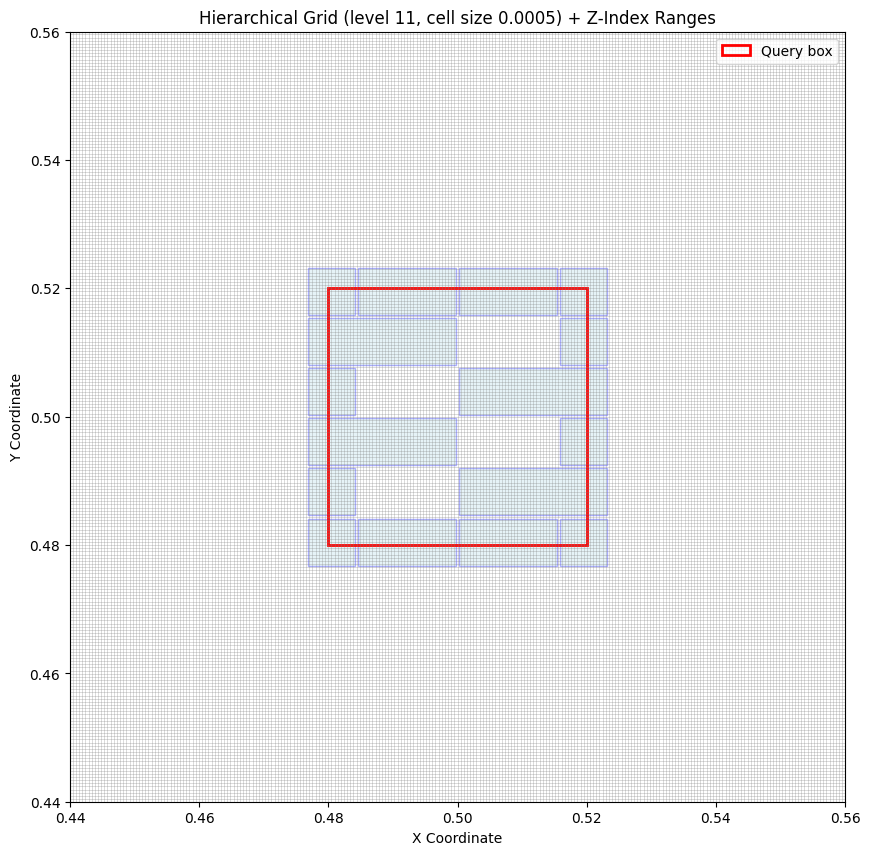

In [55]:
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt

# Create a figure and axis for the plot
fig, ax = plt.subplots(figsize=(10, 10))

# --- Draw hierarchical grid at LEVEL resolution ---
x_min_view = sample_x - BOX_HALF * 3
x_max_view = sample_x + BOX_HALF * 3
y_min_view = sample_y - BOX_HALF * 3
y_max_view = sample_y + BOX_HALF * 3

# Snap to the first grid line at or before the view extent
grid_x_start = math.floor(x_min_view / scaled_cell_size) * scaled_cell_size
grid_y_start = math.floor(y_min_view / scaled_cell_size) * scaled_cell_size

x = grid_x_start
while x <= x_max_view:
    ax.axvline(x, color='gray', linewidth=0.4, alpha=0.5)
    x += scaled_cell_size

y = grid_y_start
while y <= y_max_view:
    ax.axhline(y, color='gray', linewidth=0.4, alpha=0.5)
    y += scaled_cell_size

# Iterate through the Z-index ranges and plot rectangles
for lo, hi in morton_ranges:
    # Convert the lower and upper bounds of the range to points
    x_lo, y_lo = z_index.cell_to_point(lo)
    x_hi, y_hi = z_index.cell_to_point(hi)

    # Calculate the width and height of the rectangle
    width = x_hi - x_lo
    height = y_hi - y_lo

    # Add a rectangle to the plot
    rect = Rectangle((x_lo, y_lo), width, height, edgecolor='blue', facecolor='lightblue', alpha=0.3, linewidth=1)
    ax.add_patch(rect)

# Plot the query bounding box in red
qbox_rect = Rectangle(
    (sample_x - BOX_HALF, sample_y - BOX_HALF),
    BOX_HALF * 2, BOX_HALF * 2,
    edgecolor='red', facecolor='none', linewidth=2, label='Query box'
)
ax.add_patch(qbox_rect)

ax.set_xlim(x_min_view, x_max_view)
ax.set_ylim(y_min_view, y_max_view)
ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
ax.set_title(f"Hierarchical Grid (level {LEVEL}, cell size {scaled_cell_size:.4f}) + Z-Index Ranges")
ax.legend()
plt.show()

In [56]:
# Build a multi-range Z-order query from polygon_to_morton_ranges
_z_conditions = " OR ".join(
    f"grid_id_z BETWEEN {lo} AND {hi}" for lo, hi in morton_ranges
)
sql_z_q2 = f"""
    SELECT COUNT(*)
    FROM   bench_patches
    WHERE  ({_z_conditions});
"""

with conn.cursor() as cur:
    cur.execute("SET enable_seqscan = OFF;")

    # --- Z-order: merged Morton ranges from polygon_to_morton_ranges ---
    times_z_q2 = time_query(cur, sql_z_q2)
    cur.execute(sql_z_q2)
    z_rows = cur.fetchone()[0]

    # --- IJ composite: exact cell enumeration via = ANY ---
    sql_ij_q2 = """
        SELECT COUNT(*)
        FROM   bench_patches
        WHERE  grid_id_ij = ANY(%s);
    """
    ij_cells_arr = list(ij_cells)
    times_ij_q2 = time_query(cur, sql_ij_q2, (ij_cells_arr,))
    cur.execute(sql_ij_q2, (ij_cells_arr,))
    ij_rows = cur.fetchone()[0]

    # --- i+j indexed: two-column BETWEEN ---
    sql_ij_idx_q2 = """
        SELECT COUNT(*)
        FROM   bench_patches
        WHERE  grid_i_indexed BETWEEN %s AND %s
          AND  grid_j_indexed BETWEEN %s AND %s;
    """
    times_ij_idx_q2 = time_query(cur, sql_ij_idx_q2, (i_min, i_max, j_min, j_max))
    cur.execute(sql_ij_idx_q2, (i_min, i_max, j_min, j_max))
    ij_idx_rows = cur.fetchone()[0]

    cur.execute("SET enable_seqscan = ON;")

print("=== Query 2: all patches in spatial box ===")
print(f"  Z-order  {len(morton_ranges)} range(s)       — rows={z_rows:,}        median {median(times_z_q2)*1000:.1f} ms   {[f'{t:.3f}s' for t in times_z_q2]}")
print(f"  IJ       = ANY(cells)    — rows={ij_rows:,}       median {median(times_ij_q2)*1000:.1f} ms   {[f'{t:.3f}s' for t in times_ij_q2]}")
print(f"  i+j idx  BETWEEN         — rows={ij_idx_rows:,}   median {median(times_ij_idx_q2)*1000:.1f} ms   {[f'{t:.3f}s' for t in times_ij_idx_q2]}")
print()
print(f"Note: Z-order uses {len(morton_ranges)} merged BETWEEN range(s) from polygon_to_morton_ranges — minimal false positives.")
print("      i+j indexed uses separate single-column indexes (bitmap AND).")

=== Query 2: all patches in spatial box ===
  Z-order  16 range(s)       — rows=218,637        median 1101.0 ms   ['1.101s', '1.128s', '0.998s', '1.110s', '1.073s']
  IJ       = ANY(cells)    — rows=27       median 0.1 ms   ['0.000s', '0.000s', '0.000s', '0.000s', '0.000s']
  i+j idx  BETWEEN         — rows=159,676   median 29.6 ms   ['0.037s', '0.030s', '0.029s', '0.030s', '0.029s']

Note: Z-order uses 16 merged BETWEEN range(s) from polygon_to_morton_ranges — minimal false positives.
      i+j indexed uses separate single-column indexes (bitmap AND).


In [ ]:
with conn.cursor() as cur:
    cur.execute("SET enable_seqscan = OFF;")

    print("── Z-order multi-range BETWEEN ──────────────────────────────")
    cur.execute("EXPLAIN (ANALYZE, BUFFERS, FORMAT TEXT) " + sql_z_q2)
    for row in cur.fetchall():
        print(row[0])

    print("\n── IJ = ANY ─────────────────────────────────────────────────")
    cur.execute("EXPLAIN (ANALYZE, BUFFERS, FORMAT TEXT) " + sql_ij_q2, (ij_cells_arr,))
    for row in cur.fetchall():
        print(row[0])

    print("\n── i+j indexed BETWEEN ──────────────────────────────────────")
    cur.execute("EXPLAIN (ANALYZE, BUFFERS, FORMAT TEXT) " + sql_ij_idx_q2,
                (i_min, i_max, j_min, j_max))
    for row in cur.fetchall():
        print(row[0])

    cur.execute("SET enable_seqscan = ON;")

    print("\n── i+j unindexed BETWEEN (seq scan baseline) ────────────────")
    cur.execute("EXPLAIN (ANALYZE, BUFFERS, FORMAT TEXT) " + sql_ij_unidx_q2,
                (i_min, i_max, j_min, j_max))
    for row in cur.fetchall():
        print(row[0])

## 8 – Summary

| Query | Index | Approach | Notes |
|---|---|---|---|
| Point lookup (`LIMIT 1`) | IJ composite | `= <cell_id>` | Single B-tree probe on packed IJ key |
| Point lookup (`LIMIT 1`) | Z-order | `= <cell_id>` | Single B-tree probe on Morton key |
| Point lookup (`LIMIT 1`) | i+j indexed | `i=X AND j=Y` | Bitmap AND of two B-tree indexes |
| Point lookup (`LIMIT 1`) | i+j unindexed | `i=X AND j=Y` | Full sequential scan — baseline |
| Box scan (all rows) | Z-order | `BETWEEN z_min AND z_max` | One range scan; minor false positives at Z-curve edges |
| Box scan (all rows) | IJ composite | `= ANY(cell_list)` | One probe per cell; exact results |
| Box scan (all rows) | i+j indexed | `i BETWEEN … AND j BETWEEN …` | Bitmap AND; Postgres uses whichever index is more selective first |
| Box scan (all rows) | i+j unindexed | `i BETWEEN … AND j BETWEEN …` | Sequential scan — pure CPU/IO baseline |

**Key insight**: the Z-order index excels at bounding-box scans because Morton
encoding preserves 2-D locality in a single integer range.  Separate i/j
B-tree indexes require a bitmap AND of two range scans and incur significantly
more I/O for large boxes.  The unindexed columns provide a sequential-scan
baseline to measure the absolute cost floor.